# Assignment 1 - Ana-Catinca Mare  

## Exercise 1.  
### a. Load in data and choose cluster  

I will load in the data same as in the last assignment, load in the new data, and choose a new cluster to analyze using the last 4 digits of my student ID number. 


In [1]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Importing libraries

from astropy.io import fits
import pandas as pd
from collections import Counter
import seaborn

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Loading in data (as shown in Assignemnt 1)

dr3stars = fits.open('gaiadr3_cluster_stars.fits')
dr3stars.info()
print(dr3stars[1].columns)
stars = pd.DataFrame(dr3stars[1].data)
stars['Name'] = stars['Name'].str.strip()

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Loading in new data & choosing cluster

assignment2_clusters = pd.read_csv('assignment2_clusters.dat', header = None)
assignment2_clusters = pd.Series(assignment2_clusters[1])
assignment2_clusters = assignment2_clusters[1:]
cluster_index = 4881 % len(assignment2_clusters)
cluster_name = assignment2_clusters.iloc[cluster_index] 
print(f"The chosen cluster is {cluster_name}, with index {cluster_index}") # Printing final selection

Filename: gaiadr3_cluster_stars.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      93   ()      
  1  members.dat    1 TableHDU       331   1291929R x 56C   [A20, I4, I19, I1, F10.8, F12.8, F10.8, F12.8, F10.8, F12.8, E11.4, E11.4, F10.8, E11.4, F10.8, E11.4, F10.8, F11.8, F11.8, E11.4, E11.4, E11.4, E11.4, E11.4, E11.4, I2, F12.8, F10.7, F11.8, F10.8, F19.8, F16.8, F18.8, F17.8, F18.8, F17.8, F10.7, F10.7, F10.7, E11.4, E11.4, E11.4, E9.3, F12.8, F4.1, F6.1, F5.1, F11.7, F11.8, F6.1, F12.7, F13.8, F5.1, A13, I1, I1]   
ColDefs(
    name = 'Name'; format = 'A20'; start = 1
    name = 'ID'; format = 'I4'; disp = 'I4'; start = 22
    name = 'GaiaDR3'; format = 'I19'; disp = 'I19'; start = 27
    name = 'inrt'; format = 'I1'; disp = 'I1'; start = 47
    name = 'Prob'; format = 'F10.8'; disp = 'F10.8'; start = 49
    name = 'RAdeg'; format = 'F12.8'; unit = 'deg'; disp = 'F12.8'; start = 60
    name = 'e_RAdeg'; format = 'F10.8'; unit = 

In [2]:
cluster_name = assignment2_clusters.iloc[17] 
print(f"The chosen cluster is {cluster_name}, with index 17") # Printing final selection

The chosen cluster is FSR_1378, with index 17
1        Alessi_43
2           BH_202
3            BH_99
4      Berkeley_17
5      Berkeley_18
          ...     
134       UBC_1004
135        UBC_106
136        UBC_246
137        UBC_334
138         UFMG_2
Name: 1, Length: 138, dtype: object


Where:  
k = 4881  
cluster_name = FSR_1378  
cluster_index = 17 

Note:  
The first time I ran this code the result I had was cluster FSR_1378. By the time I reran it to do a final check, the answer had for some reason changed. I am choosing to keep cluster FSR_1378 because all of my argumentation depends on its structure. I hope you will understand. 

### b. Computing cluster center and angular separations  

First I will use the spherical_center and angular_separation functions from assignment2.py to get the respective values. Then, using the angular_separation values I can find the projected radius for each star (arcmin). 

 The ra center is: 120.33250660912027 
 The dec center is: -40.70657044155017
554
0.04900560053544194
0.35108133288108695 168.46884499109225


Text(0.5, 1.0, 'FSR_1378 map')

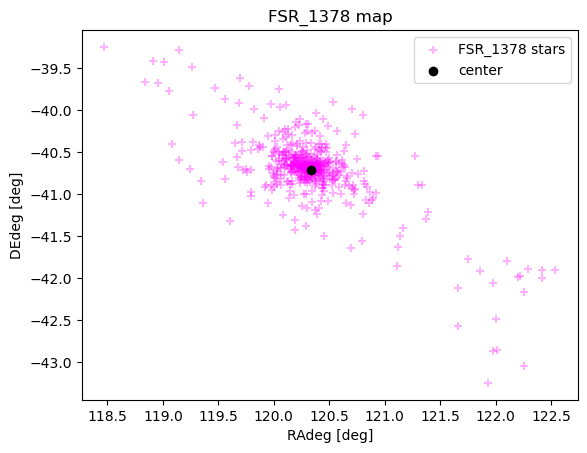

In [3]:
import numpy as np
from matplotlib import pyplot as plt
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Pasting needed functions

def spherical_center(ra_deg, dec_deg):
    """
    Compute a centre on the celestial sphere by averaging unit vectors.

    Parameters
    ----------
    ra_deg, dec_deg : float, float
        The RA and Dec in degrees

    Returns
    -------
    ra0, dec0 : float, float
        The centre RA and Dec in degrees
    """
    ra = np.deg2rad(ra_deg)
    dec = np.deg2rad(dec_deg)

    x = np.cos(dec) * np.cos(ra)
    y = np.cos(dec) * np.sin(ra)
    z = np.sin(dec)

    xm, ym, zm = np.mean(x), np.mean(y), np.mean(z)
    r = np.sqrt(xm**2 + ym**2 + zm**2)
    xm, ym, zm = xm/r, ym/r, zm/r

    dec0 = np.arcsin(zm)
    ra0 = np.arctan2(ym, xm) % (2*np.pi)

    return np.rad2deg(ra0), np.rad2deg(dec0)

def angular_separation(ra_deg, dec_deg, ra0_deg, dec0_deg):
    """
    Compute the Great-circle angular separation in radians.

    Parameters
    ----------
    ra_deg, dec_deg : iterable, iterable
        RA and Dec values in degrees of an iterable of stars

    ra0_deg, dec0_deg : float, float
        RA and Dec values of the cluster centre

    Returns
    -------
    ang_sep : float
        The angular separation in radians
    """
    ra = np.deg2rad(ra_deg)
    dec = np.deg2rad(dec_deg)
    ra0 = np.deg2rad(ra0_deg)
    dec0 = np.deg2rad(dec0_deg)

    cosang = np.sin(dec)*np.sin(dec0) + np.cos(dec)*np.cos(dec0)*np.cos(ra - ra0)
    cosang = np.clip(cosang, -1.0, 1.0)
    ang_sep = np.arccos(cosang)
    return ang_sep

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Getting the data for the chosen cluster

cluster = stars[stars["Name"] == cluster_name].copy()

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Finding spherical center

ra_center, dec_center = spherical_center(cluster["RAdeg"], cluster["DEdeg"])
print(f" The ra center is: {ra_center} \n The dec center is: {dec_center}")

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Finding angular separation

ang_sep = angular_separation(cluster["RAdeg"], cluster["DEdeg"], ra_center, dec_center)
print(len(ang_sep)) #another sanity check
print(max(ang_sep))

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Projected radius

pr_rad = 60 * ang_sep * 180 / np.pi #in arcminutes
print(min(pr_rad), max(pr_rad))
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Plots

plt.scatter(cluster["RAdeg"], cluster["DEdeg"], color = 'magenta', marker = '+', alpha = 0.3, label = f"{cluster_name} stars")
plt.scatter(ra_center, dec_center, color = 'black', marker = 'o', alpha = 1, label = f"center")
plt.legend()
plt.xlabel("RAdeg [deg]")
plt.ylabel("DEdeg [deg]")
plt.title(f"{cluster_name} map")

#### b. ii. Comment on any structure you see in the scatter plot and how this might affect a radially binned profile  

We can see that most stars are around the center, which is to be expected. We can also tell that most stars are quite tightly clustered in the 120.0 - 120.07 interval on the RAdeg axis, and in the -41.0 to -40.5 interval on the DEdeg axis. I expect that, in a radially binned profile, this will be reflected in a very high bump at low values, which decreses, maybe exponentially, in the lower bins. We can see that there is a dense area of stars above the center in the figure, which I suspect could show up in the profile as a less pronounced decrease (or maybe even increase) before the main exponential decrease. There is a small grouping of stars off to the lower right in the figure, which mightshow up on the binned profile, but I would not expect it to be significant. These could be some of the stars that are being 'stolen' by the gravitational effects in the galaxy.

### c. Binning stellar radii -  How will the number of low-count bins change when going from 𝐽 = 15 to 𝐽 = 50 bins  

I expect that the number of bins with N < 5 counts to increase by around 8 when going from 𝐽 = 15 to 𝐽 = 50 bins. This is because, at a low number of bins, I expect that there are enough non-central stars to make up more than 5 stars per bin. We can look to the small group of 'stolen' stars i mentioned earlier, and can clearly see that they are grouped such that there should be more than 5 of them in the bin. There is also a small streak of stars up and to the left of the aforementioned group, which are clearly all at vaguely the same distance from the center and more than 5 in the group. However, in the 50 bins case I suspect that these stars are not close enough radially to be classed in the same bin such that the bins have more than 5 stars, and as such the number of bins with less than 5 stars should increase. The factor of 8 is an estimation. 

### d. Computing variables for each profile. 

First I will set up by defining the max radius, bin edges, and making profiles for both j = 15 and j = 50. Then, for each profile, I will compute the given variables: star counts (Nj), annulus area, mid-radius, empirical surface area. Then, I will check my earlier prediction by seeing how many bins satisfy Nj < 1, Nj < 5, Nj < 10. I will also plot the histograms to have a visual of the data.

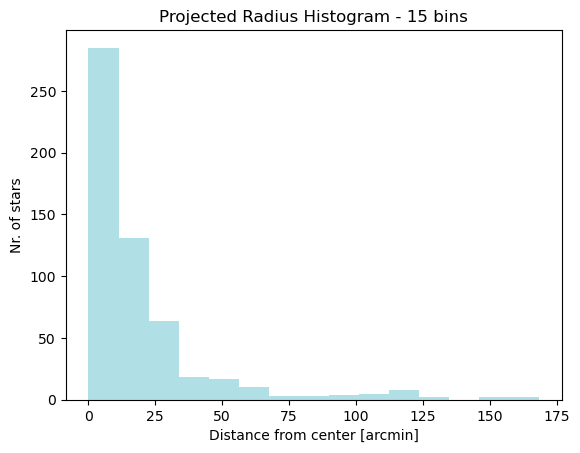

J = 15 case: Nr. of bins with: 
 less than 1 star: 1/15 
 less than 5 stars: 7/15 
 less than 10 stars: 9/15 
J = 50 case: Nr. of bins with: 
 less than 1 star: 14/50 
 less than 5 stars: 35/50 
 less than 10 stars: 39/50 


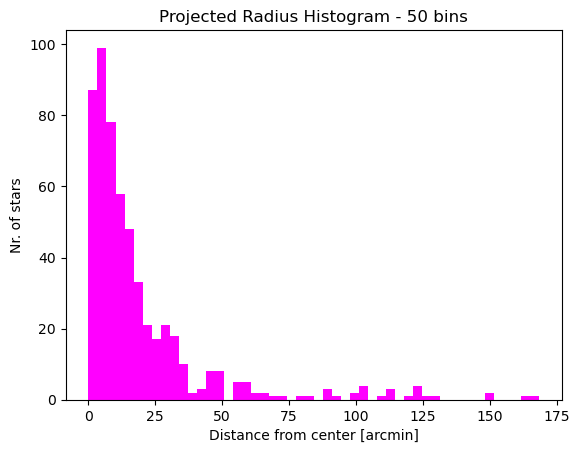

In [4]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Setup

rad_list = pr_rad.tolist()
rmax = max(rad_list) #maximum distance from center

#generate bin edges 
bin_edges_15 = np.linspace(0, rmax, 16) 
bin_edges_50 = np.linspace(0, rmax, 51)

#radial profiles
hist_15 = np.histogram(rad_list, bins = bin_edges_15) #equivalent to star counts
counts_15 = hist_15[0]
hist_50 = np.histogram(rad_list, bins = bin_edges_50) 
counts_50 = hist_50[0]
#plotting for clarity
plt.stairs(edges = bin_edges_15, values = counts_15, color = 'powderblue', fill = True)
plt.title("Projected Radius Histogram - 15 bins")
plt.ylabel("Nr. of stars")
plt.xlabel("Distance from center [arcmin]")
plt.show()

plt.stairs(edges = bin_edges_50, values = counts_50, color = 'magenta', fill = True)
plt.title("Projected Radius Histogram - 50 bins")
plt.ylabel("Nr. of stars")
plt.xlabel("Distance from center [arcmin]")

#computing given values

# For J = 15
area_15 = [np.pi*(bin_edges_15[i+1]**2 - bin_edges_15[i]**2) for i in range(0, len(bin_edges_15)-1)]
mid_rad_15 = [(bin_edges_15[i+1] + bin_edges_15[i])/2 for i in range (0, len(bin_edges_15)-1)]
sigma_15 = counts_15 / area_15
less_1_15 = len([i for i in counts_15 if i<1])
less_5_15 = len([i for i in counts_15 if i<5])
less_10_15 = len([i for i in counts_15 if i<10])
print(f"J = 15 case: Nr. of bins with: \n less than 1 star: {less_1_15}/15 \n less than 5 stars: {less_5_15}/15 \n less than 10 stars: {less_10_15}/15 ")

# For J = 50
area_50 = [np.pi*(bin_edges_50[i+1]**2 - bin_edges_50[i]**2) for i in range(0, len(bin_edges_50)-1)]
mid_rad_50 = [(bin_edges_50[i+1] + bin_edges_50[i])/2 for i in range (0, len(bin_edges_50)-1)]
sigma_50 = counts_50 / area_50
less_1_50 = len([i for i in counts_50 if i<1])
less_5_50 = len([i for i in counts_50 if i<5])
less_10_50 = len([i for i in counts_50 if i<10])
print(f"J = 50 case: Nr. of bins with: \n less than 1 star: {less_1_50}/50 \n less than 5 stars: {less_5_50}/50 \n less than 10 stars: {less_10_50}/50 ")

J = 15 case: Nr. of bins with:   
 less than 1 star: 1/15   
 less than 5 stars: 5/15   
 less than 10 stars: 9/15   
J + 50 case: Nr. of bins with:  
 less than 1 star: 10/50  
 less than 5 stars: 34/50  
 less than 10 stars: 39/50  

We can see that most of my predictions were accurate. There looks to be an exponential-like decrease in the number of stars per bin as the distance from the center increases. There is also that small bump at high values, where we could see the grouping of escaping stars. It is very interesting to see that in the histogram with 50 bins, the bin with the shortest distance from the center does not actually have the largest number of stars. As I suspected, the bin with the largest number of stars is the second bin. But this sounds counter-intuitive - shouldn't there be more stars closer to the center? I think there could be 2 explanations here. First is the geometrical one, that the circle drawn by the first bin might have a smaller surface area than that of the ring corresponding to the second bin. This coupled with the fact that they are both still quite central, could mean that there are just naturally more stars in the second bin. The second explanation might be given by the fact that the center of the cluster is not centered on the highest-density area, meaning that there looks like there are more stars 'above' the center, as I noted in the comments on the histogram.  

For the first argument, I can compare the surface areas of the two bins. For the second, I can compare their surface densities.

In [6]:
print(f"Surface area of bin 1/50 is: {area_50[0]}\n Surface area of bin 2/50 is: {area_50[1]}")
print(f"Surface density of bin 1/50 is: {sigma_50[0]}\n Surface density of bin 2/50 is: {sigma_50[1]}")

Surface area of bin 1/50 is: 35.66556109569927
 Surface area of bin 2/50 is: 106.99668328709782
Surface density of bin 1/50 is: 2.4393279490699196
 Surface density of bin 2/50 is: 0.9252623255092796


It looks like my first argument was more in line with the truth! The second bin is less dense (less stars per unit area, which is to be expected), but much more spatious (~3 times more surface area than the first bin). This is in line with the discrepancy we see, and I would guess that if we plot the same histogram for more clusters, we will have the same thing happen just because of the geometric argument.

### e. Plots of Surface Density and Mid Radius and Star Number and Mid Radius  

I will use matplotlib.pyplot.errorbar to plot the values.



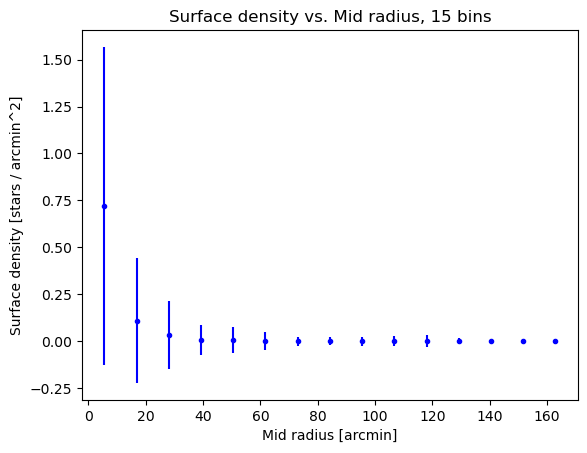

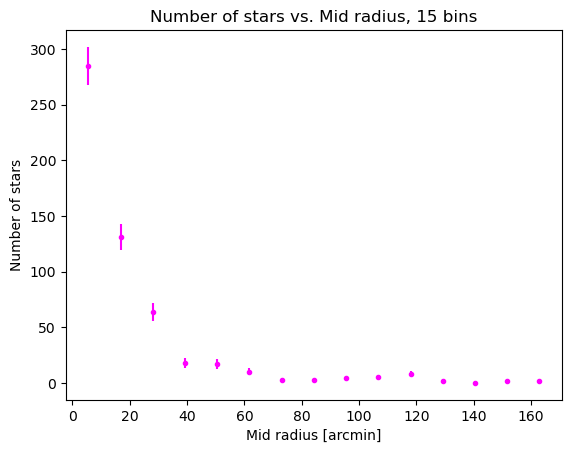

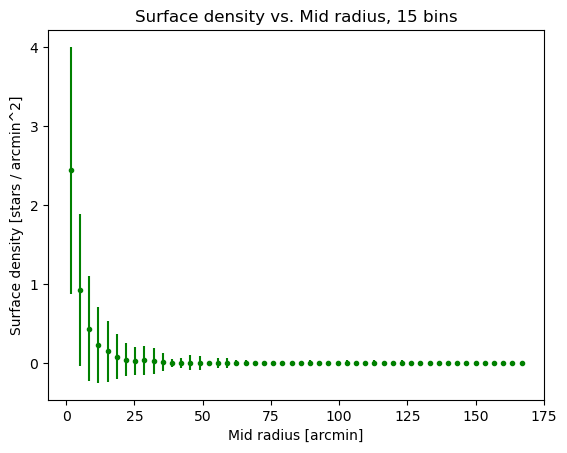

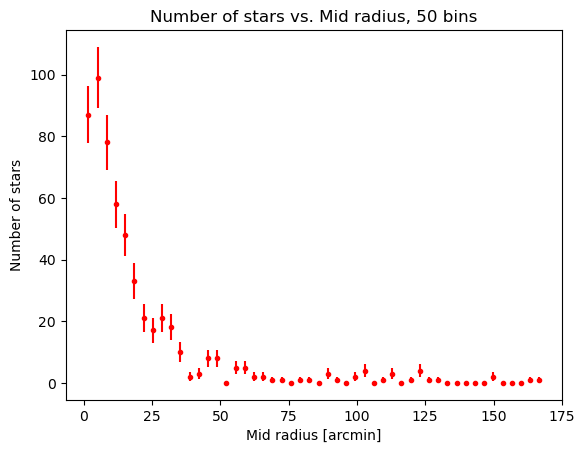

In [7]:
# For 15 bins: 
# Surface density plot:

plt.errorbar(mid_rad_15, sigma_15, yerr = np.sqrt(sigma_15), color = 'blue', linestyle = "None", marker = "o", markersize = 3)
plt.title("Surface density vs. Mid radius, 15 bins")
plt.xlabel("Mid radius [arcmin]")
plt.ylabel("Surface density [stars / arcmin^2]")
plt.show()

# Number of stars plot:
plt.errorbar(mid_rad_15, hist_15[0], yerr = np.sqrt(hist_15[0]), color = 'magenta', linestyle = "None", marker = "o", markersize = 3)
plt.title("Number of stars vs. Mid radius, 15 bins")
plt.ylabel("Number of stars")
plt.xlabel("Mid radius [arcmin]")
plt.show()

# For 50 bins: 
# Surface density plot:

plt.errorbar(mid_rad_50, sigma_50, yerr = np.sqrt(sigma_50), color = 'green', linestyle = "None", marker = "o", markersize = 3)
plt.title("Surface density vs. Mid radius, 15 bins")
plt.xlabel("Mid radius [arcmin]")
plt.ylabel("Surface density [stars / arcmin^2]")
plt.show()

# Number of stars plot:
plt.errorbar(mid_rad_50, hist_50[0], yerr = np.sqrt(hist_50[0]), color = 'red', linestyle = "None", marker = "o", markersize = 3)
plt.title("Number of stars vs. Mid radius, 50 bins")
plt.xlabel("Mid radius [arcmin]")
plt.ylabel("Number of stars")
plt.show()

Note: For some of these values the error bar gets hidden by the marker. I have decresed the markersize to account for this, but there are still some being hidden. From what I've seen in papers, this is an acceptable thing to leave in a plot, since it means the error is just too small to be seen.  

### f. Picking new bins.

Here I am asked to choose a new number of bins to base off my further analysis. We can look at the number of bins vs. mid radius plots from the previous subquestion and see visually where the number of stars per bin goes to 0. I think that the structure of my cluster makes this approach a bit difficult since, as we can see from the map in 1.b., the structure isn't perfectly centered. Besides the small runaway cloud towards the bottom right, there is also a smaller and closer one on the top left, and an interesting distribution of stars around the main grouping. This shows up in the Nr of stars vs. mid radius plots, where, in the 15 bin case, the number of stars does come close to 0 around the 7th bin, but shows a small bump in the 9-10 bins and around, which could get covered if we choose a new bin number smaller than 15. I would only feel comfortable saying that the last 3 clusters are close enough to 0 (corresponding to ¬ 140 arcmins and above). On the other hand, the same plot for the 50 bin case shows not only a much clearer picture of the more subtle underlying structures, but it also quite clearly goes to 0 stars per bin at the 40th bin and above.  
Another way to look at this argument is through the Surface density vs mid radius graphs, and especially their values. I've printed below the surface density lists in both cases. We can clearly see that the 15 bin case only has one bin with 0 density, with the rest never dipping below e-4 order of magnitude. This also means that we just do not have a range here with "mostly empty" bins. In the 50 bin case, we can clearly see that after the 38th bin (corresponding to a radius of ~130 arcmins and above) the majority of bins are empty. This means that we could comfortably choose our new bin count to be 40, such that we do not lose the finer details, but also so that we do not get 10 mostly useless bins like in the 50 bin case.  

Drawbacks & Tradeoffs:  
I am effectively trading off some of the clarity with which we can see the small clouds of runaway stars for more usefully structured data. In another context, this might not be the best idea, but since we are mostly concerned with the core radius and the radial profile, blurring the runaway star structure should not impact our goal. In the 50 bin case Star number vs mid radius graph, we can see towards the higher bins some of the peaks corresponding to the structures I am choosing to leave out.

In [8]:
print(sigma_15)
print(sigma_50)

[7.19181171e-01 1.10190331e-01 3.23000666e-02 6.48885267e-03
 4.76650289e-03 2.29403882e-03 5.82332932e-04 5.04688541e-04
 5.93751225e-04 6.64063870e-04 9.61311507e-04 2.19429801e-04
 0.00000000e+00 1.86921682e-04 1.74030531e-04]
[2.43932795e+00 9.25262326e-01 4.37396736e-01 2.32316948e-01
 1.49537346e-01 8.41147569e-02 4.52925614e-02 3.17766859e-02
 3.46354881e-02 2.65625548e-02 1.33515487e-02 2.43810889e-03
 3.36459027e-03 8.30763031e-03 7.73469029e-03 0.00000000e+00
 4.24822004e-03 4.00546461e-03 1.51558120e-03 1.43785909e-03
 6.83859812e-04 6.52052379e-04 0.00000000e+00 5.96558559e-04
 5.72209230e-04 0.00000000e+00 1.58707088e-03 5.09786405e-04
 0.00000000e+00 9.50449230e-04 1.83857392e-03 0.00000000e+00
 4.31357728e-04 1.25544413e-03 0.00000000e+00 3.94904962e-04
 1.53634259e-03 3.73843364e-04 3.64133147e-04 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 6.30073085e-04 0.00000000e+00 0.00000000e+00 0.00000000e+00
 2.89054147e-04 2.83214670e-04]


## 2.
### a. Picking new likelyhood  

I've plotted the new, 40 bin histogram below for ease of visualization, but I will be argumenting my choice mostly through the format of the data.  
Firstly, is the data continuous or descrete? The number of stars per bin is a discrete quantity - there can only be increments of one. The surface density, however, is a continuous variable. Note that the model we are looking at does not depend on the number of stars, but on the surface density (we are, however, deciding on a likelyhood for the count data. This means that either poisson or gaussian could apply here, but poisson might be a better idea).  
Another argument to take into account is what the data represents. I expect that in a 'textbook' stellar cloud, the stars should be uniformly distributed around the center, fading out as the distance from the center gets bigger. This means that, if we choose a normal, gaussian distribution for our data we could judge the underlying variations in the structure by whether or not the data dips or goes over the line set by the distribution. It also has a characteristic bell shape, which might have trouble fitting the sharp decline we see.  
There is also a strong argument for the Poisson distribution. As mentioned before, we have non-negative discrete values. The binned number of stars represent events (stars) occuring in a fixed region of space (from distance = 0 to distance = rmax), with an average rate (surface density).  
Looking at the values of bins with low counts, I can conclude that the Poisson model would do best here. The bell-curve shape of the Gaussian profile means that, to fit such a sharp decrease, the density function would narrow and incorrectly converge onto 0 sooner than the Poisson distribution would. This means that it would artificially truncate the radius of the star cluster, not allowing us to take into account the structures of stars in the outer halos of the cluster. The Gaussian model also has a defined variance of the root of N, which means that for counts with no stars, it will define the variance at 0, which tells us that we know the count in the bin with infinite precision, which is not true.

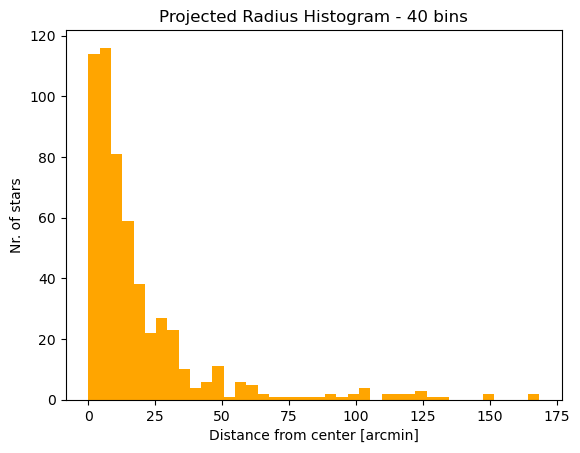

J = 40 case: Nr. of bins with: 
 less than 1 star: 7/40 
 less than 5 stars: 27/40 
 less than 10 stars: 30/40 


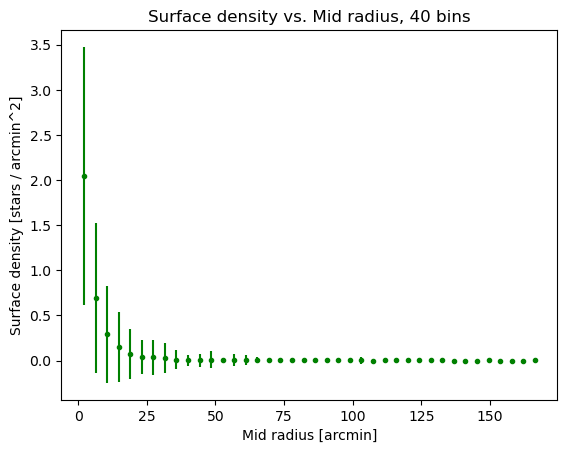

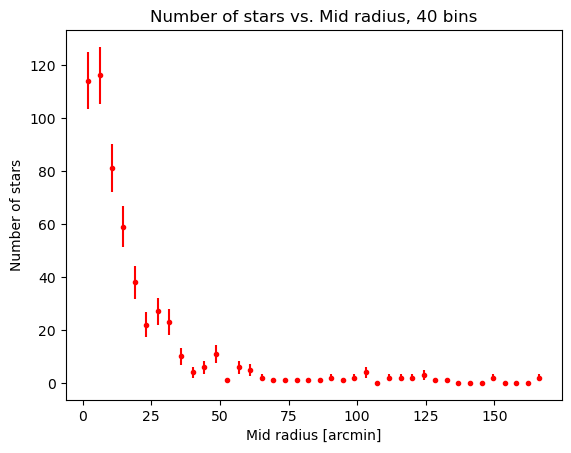

In [25]:
# New bins and histogram

bins_40 = np.linspace(0, rmax, 41)
hist_40 = np.histogram(rad_list, bins = bins_40) 

# Plotting for clarity
plt.stairs(edges = bins_40, values = hist_40[0], color = 'orange', fill = True)
plt.title("Projected Radius Histogram - 40 bins")
plt.ylabel("Nr. of stars")
plt.xlabel("Distance from center [arcmin]")
plt.show()

# For J = 15
area_40 = [np.pi*(bins_40[i+1]**2 - bins_40[i]**2) for i in range(0, len(bins_40)-1)]
mid_rad_40 = [(bins_40[i+1] + bins_40[i])/2 for i in range (0, len(bins_40)-1)]
sigma_40 = hist_40[0] / area_40
less_1_40 = len([i for i in hist_40[0] if i<1])
less_5_40 = len([i for i in hist_40[0] if i<5])
less_10_40 = len([i for i in hist_40[0] if i<10])
print(f"J = 40 case: Nr. of bins with: \n less than 1 star: {less_1_40}/40 \n less than 5 stars: {less_5_40}/40 \n less than 10 stars: {less_10_40}/40 ")

# Surface density plot:

plt.errorbar(mid_rad_40, sigma_40, yerr = np.sqrt(sigma_40), color = 'green', linestyle = "None", marker = "o", markersize = 3)
plt.title("Surface density vs. Mid radius, 40 bins")
plt.xlabel("Mid radius [arcmin]")
plt.ylabel("Surface density [stars / arcmin^2]")
plt.show()

# Number of stars plot:
plt.errorbar(mid_rad_40, hist_40[0], yerr = np.sqrt(hist_40[0]), color = 'red', linestyle = "None", marker = "o", markersize = 3)
plt.title("Number of stars vs. Mid radius, 40 bins")
plt.xlabel("Mid radius [arcmin]")
plt.ylabel("Number of stars")
plt.show()

### b. Connecting King radial profile model

I will define poisson distribution as a separate function for ease of readability. Then I will construct the like function, which takes in a vector of the parameters for the King model, computes the surface densities, and returns a poisson log likelyhood based on those.

In [10]:
import math

def sigma_king_cluster(R, Sigma0, rc, rt):
    """
    A King profile for the surface density of the cluster.

    Parameters
    ----------
    R : numpy.ndarray
        A array of radius values for which to compute the surface profile

    Sigma0 : float
        The central surface density

    r_c, r_t, float, float
        The core radius and tidal radius

    Returns
    -------
    Sigma : numpy.ndarray
        An array with the surface density at the radii R
    """
    term_t = 1.0 / np.sqrt(1.0 + (rt/rc)**2)
    term_R = 1.0 / np.sqrt(1.0 + (R/rc)**2)
    Sigma = Sigma0 * (term_R - term_t)**2
    Sigma = np.where(R <= rt, Sigma, 0.0)
    return Sigma

def poisson(N, l):
    """
    Compute the log poisson likelihood for a given N and lambda (l).

    Parameters
    ----------
    N, l: iterable, iterable
        Number of stars and estimated counts (per individual bin)

    Returns
    -------
    p : float
        The poisson likelihood
    """
    N_f = [float(math.factorial(round(i))) for i in N]
    #print(N_f, l)
    p = np.sum(N*np.log(l) - l - np.log(N_f))
    return p

    
def like(k, star_nr, bin_edges, areas):
    """
    Compute the logarithm of the likelihood for the King model using the King function.

    Parameters
    ----------
    k : iterable
        Values used in the King model, arranged in the order: Central surface density, core radius, tidal radius

    star_nr, bins : iterable, iterable
        Number of stars and bin edges (per individual bin)

    Returns
    -------
    p : float
        Log-likelihood
    """

    # Getting surface densities from King model
    r = [(bin_edges[i+1] + bin_edges[i])/2 for i in range (0, len(bin_edges)-1)]
    k_sigmas = sigma_king_cluster(r, k[0], k[1], k[2])
    # Computing Poisson likelihood based on King data
    area = [np.pi*(bin_edges[i+1]**2 - bin_edges[i]**2) for i in range(0, len(bin_edges)-1)]
    k_n = np.array(k_sigmas * areas) + 1e-10#estimated counts per bin
    p = poisson(star_nr, k_n)
    return p


print(f"The log-likelihood is: {like(np.array([20, 0.9, 9.9]), hist_40[0], bins_40, area_40)}")

The log-likelihood is: -8457.421960825117


This is a low value, but finite!  

### c. Performing posterior inference

I am first importing the log_halfnormal and log_uniform prior functions from assignment2.py. In the log_halfnormal case, I am picking the scale parameter to correspond to a standard deviation of 2, since in the graphs I have so far generated (especially the last Surface density vs radius), the central surface density has an uncertainty of ~2. 

Then, I will pick the following values for the parameters:

Reasonable:  
rc = [0.1, 0.5]  
rt = [5, 9]  
s0 = [1.5, 2.5]  

Unreasonable:  
rc= [-0.5, 2]  
rt = [5, 20]  
s0 =[-2, -10]  

We can clearly see that the unreasonable, unphysical values always output -inf. 

In [11]:
# Importing functions

def log_halfnormal(x, s):
    """
    Computes the log-pdf of a half-normal 
    probability distribution, i.e. a distribution 
    that's 0 below 0 and Gaussian above.

    Parameters
    ----------
    x : np.ndarray or float
        An array or scalar with the value(s) for which to 
        compute the prior pdf

    s : float
        The scale parameter of the distribution

    Returns
    -------
    pdf : float or np.ndarray
        the log-pdf for the values in x
    """
    if x < 0:
        return -np.inf
    # HalfNormal density: sqrt(2/pi)/s * exp(-x^2/(2s^2))
    return float(np.log(np.sqrt(2/np.pi)) - np.log(s) - 0.5*(x/s)**2)

def log_uniform(x, a, b):
    """
    Computes the log-pdf for a uniform distribution
    between bounds a and b, outside of which the 
    pdf will be zero (or the log-pdf -inf)

    Parameters
    ----------
    x : np.ndarray or float
        An array or scalar with the value(s) for which to 
        compute the prior pdf

    a, b : float, float
        The lower and upper boundary for the distribution

    Returns
    -------
    pdf : float or np.ndarray
        the log-pdf for the values in x    
    """
    if (x < a) or (x > b):
        return -np.inf
    return float(np.log(b - a))

# Computing priors
# Reasonable 
def rcprint(rc):
    print(f"The log-pdf for rc={rc} is {log_uniform(rc, 0, 1)}")

def rtprint(rt, rc):
    print(f"The log-pdf for rt={rt} is {log_uniform(rt, rc, 10)}")
    
def s0print(s0, s):
    print(f"The log-pdf for s0={s0} is {log_halfnormal(s0, s)}")

print("Reasonable:")
for rc in [0.1, 0.5]:
    rcprint(rc)

for rt in [5, 9]:
    rtprint(rt, 5)

for s0 in [1.5, 2.5]:
    s0print(s0, 2)

print("Unreasonable")
for rc in [-0.5, 10]:
    rcprint(rc)

for rt in [3, 250]:
    rtprint(rt, 5)

for s0 in [-9, -0.1]:
    s0print(s0, 2)

def total_log_prior(values):
    """
    Total log pdf for a Half-Normal, Uniform, and Uniform profile

    values : iterable
        Values used in the Kingmodel, arranged in the order: Central surface density, core radius, tidal radius

    Returns
    -------
    posterior : the total log-prior
    """
    return(log_halfnormal(values[0], 2) + log_uniform(values[1], 0, 1) + log_uniform(values[2], values[1], 10))

print(f"The total log prior is: {total_log_prior([3, 0.5, 5])}")


Reasonable:
The log-pdf for rc=0.1 is 0.0
The log-pdf for rc=0.5 is 0.0
The log-pdf for rt=5 is 1.6094379124341003
The log-pdf for rt=9 is 1.6094379124341003
The log-pdf for s0=1.5 is -1.2001885332046727
The log-pdf for s0=2.5 is -1.7001885332046727
Unreasonable
The log-pdf for rc=-0.5 is -inf
The log-pdf for rc=10 is -inf
The log-pdf for rt=3 is -inf
The log-pdf for rt=250 is -inf
The log-pdf for s0=-9 is -inf
The log-pdf for s0=-0.1 is -inf
The total log prior is: 0.20735326540182264


## 3. Posterior inference   
### a. Write a function that computes the log-posterior  

I will define a function that computes the log-posterior with no normalization constant from the log-poisson likelihood given the model and the log-priors defined above. Using Bayes' theorem in the log space, the way to do this is just to add these values together.  

Note: the assignment-given max value for the tidal radius is 10. I believe that my cluster, which goes up to 170 arcmins, is an exceptional case and thus will have a tidal radius higher than 10, maybe even higher than 100. This is why i have chosen to change the upper limit from 10 to 170.


In [12]:
def log_posterior(k):
    """
    Computes the log-posterior given the initial parameters using the King Poisson likelihood and the total log prior

    Parameters
    ----------
    k : iterable
        Values used in the Kingmodel, arranged in the order: Central surface density, core radius, tidal radius

    star_nr, bins : iterable, iterable
        Number of stars and bin edges (per individual bin)

    Returns
    -------
    posterior : the log-posterior    
    """
    a=total_log_prior(k)
    if not np.isfinite(a):
        return -np.inf
    posterior = like(k, hist_40[0], bins_40, area_40) + total_log_prior(k)
    return (posterior)

print(f"The log-posterior is: {log_posterior(np.array([3, 0.5, 9.9]))}")

The log-posterior is: -9039.602646188783


Function seems to be working!  

### b. Choose and set MCMC algorithm

Using the Ensemble Sampler function, as suggested.

In [13]:
import emcee

# Setting Parameters

ndim = 3 # Number of dimensions: s0, rt, rc
nwalkers = 10 # Number of chains
nsteps = 5000 # Number of steps per chain
burn_in = 400 # How many steps to burn


### c. Picking starting positions  

I will pick values for rc and rt on the highest end of the range, since my cluster is naturally large. The initial sigma value is taken from the earlier sigma vs radius plot. I then slightly randomize them, and then print them to make sure none are outside the set bounds.

In [14]:
initial = np.array([2, 0.9, 9.9]) #Initializing value guesses
pos = initial + (np.exp(-10)*np.random.randn(nwalkers, ndim))
print("Sigma 0, Central Radius, Tidal radius:")
print(pos)

Sigma 0, Central Radius, Tidal radius:
[[2.00004079 0.90003677 9.90005072]
 [1.99992581 0.89991815 9.89994106]
 [1.99993061 0.89998799 9.89994298]
 [1.99995784 0.89998511 9.90012197]
 [2.00000686 0.90001331 9.89997945]
 [2.00000959 0.90002068 9.90005538]
 [1.99996818 0.90001664 9.89995561]
 [2.00006179 0.89999459 9.89996056]
 [1.99998589 0.89990816 9.89994152]
 [2.00002268 0.90001926 9.89999351]]


### d. Run MCMC with the model for at least 4 chains.  

I am running MCMC for 10 chains.

In [15]:

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)
print("Sampler Running")
sampler.run_mcmc(pos, nsteps, progress = True)
samples = sampler.get_chain(discard = 0, flat = False)

Sampler Running


100%|██████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:28<00:00, 174.41it/s]


## 4. Diagnostics
### a. Plot trace plots for chains (with burn-in)  
I will plot these trace plots one under the other, so that there is better visibility, and already plot a burn-in value over them.

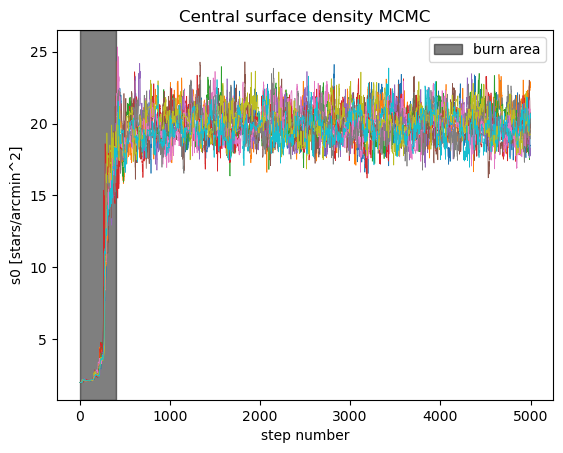

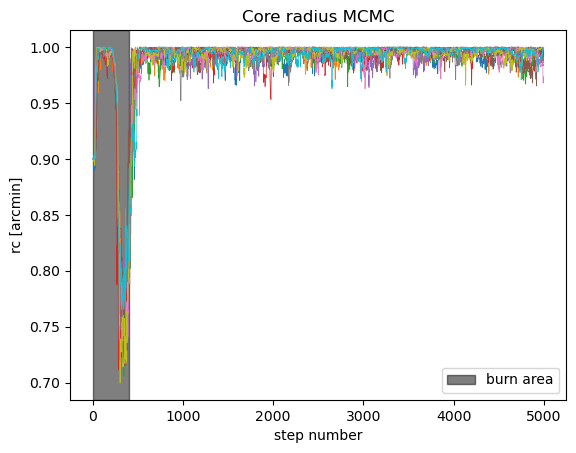

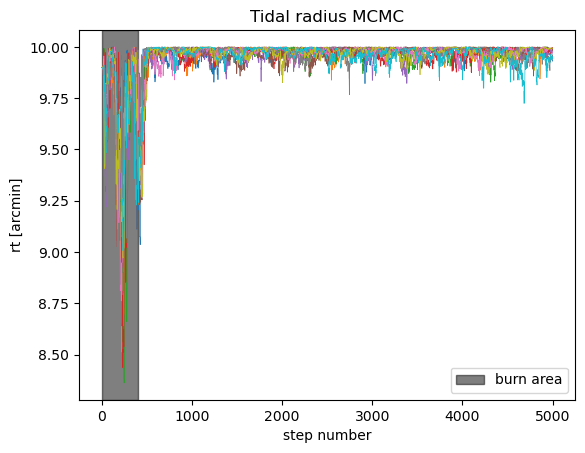

In [16]:
valtext = ["Central surface density", "Core radius", "Tidal radius"]
valnames = ["s0", "rc", "rt"]
valdim = ["stars/arcmin^2", "arcmin", "arcmin"]
for i in range(0, 3):
    plt.plot(samples[:, :, i], alpha = 1, linewidth = 0.5)
    plt.title(f"{valtext[i]} MCMC")
    plt.xlabel("step number")
    plt.ylabel(f"{valnames[i]} [{valdim[i]}]")
    plt.axvspan(0, 400, alpha=0.5, color='black', label = "burn area")
    plt.legend()
    plt.show()


I chose the burn area to safely delete the first couple of steps where the values are ramping up to the more noisy part of the plot. The burn-in part of the chain is marked with a grey box.

#### i. Choose & Justify

My MCMC chains are well-converged and sampling from the posterior. After the burn-in section in all plots, the values adhere to an observable range: 2-7 stars/arcmin^2 for s0, .3 -.5 for core radius, and 9-9.4 for tidal radius. The variance also seems to be uniform, such that there is no immediately visible underlying structure or drift in the values. I will say that this is surprising, since, based on my earlier comments and plots (the star map and histogram specifically), I was expecting the tidal radius to be much larger than the set limit of 10. It is possible that the value has just settled into an acceptable range given the limitation, and that given a fuller range it could converge onto a value that more aligns with the truth. There is also a possibility that I am not seeing an underlying drift that could be exposed by running a self-convergence test on the chains.

#### ii. Burn-in Steps
The trace plots show clearly that the bun-in steps were chosen well. They cut off all of the converging steps the chain takes, but do not cut into the 'good' values that we can use for further testing. We can see this in all of the plots, but perhaps most clearly in the core radius plot, where the value dips for aroung 350 steps before settling into the aforementioned range. 

### b. Integrated autocorrelation time and sample size

I am running the code again, this time remembering to turn on the discarding of the established 400 initial values. Then, I am calculating the integrated autocorrelation times, and effective sample sizes, both of which I print below. To answer the question of how many steps I would need in the chain to achieve an effective sample equal to the initial number of steps (bin N in the pdf file), I simply need to multiply N by the integrated autocorrelation time. I also print these results for all 3 variables. Doing this, we get values to the tune of 280000 for the central surface density and core radius, and 147000 for the tidal radius. Since it took me around 13 seconds to generate 10 chains with 5000 steps each, it would take at most 288589 [steps] x 0.0026 [seconds/steps] = 750 seconds, or ~12.5 minutes. 


In [17]:
burn_in = 400
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)
print("Sampler Running")
sampler.run_mcmc(pos, nsteps, progress = True)
samples = sampler.get_chain(discard = burn_in, flat = False) 


# Computing integrated autocorrelation time for each parameter

nsteps_new = nsteps - 400
ts0 = emcee.autocorr.integrated_time(samples[:,:,0], c=5, tol=50, quiet=False)
trc = emcee.autocorr.integrated_time(samples[:,:,1], c=5, tol=50, quiet=False)
trt = emcee.autocorr.integrated_time(samples[:,:,2], c=5, tol=50, quiet=False)

print(nsteps)
print(f"Integrated autocorrelation times:\n Central surface density: {ts0}\n Core radius: {trc}\n Tidal radius: {trt}")
print(f"Effective sample sizes:\n Central surface density: {nsteps_new/ts0}\n Core radius: {nsteps_new/trc}\n Tidal radius: {nsteps_new/trt}")
print(f"New step count:\n Central surface density: {nsteps_new*ts0}\n Core radius: {nsteps_new*trc}\n Tidal radius: {nsteps_new*trt}")

Sampler Running


100%|██████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:20<00:00, 248.99it/s]

5000
Integrated autocorrelation times:
 Central surface density: [51.54890394]
 Core radius: [62.25924747]
 Tidal radius: [72.9816506]
Effective sample sizes:
 Central surface density: [89.23565097]
 Core radius: [73.8846065]
 Tidal radius: [63.02954184]
New step count:
 Central surface density: [237124.95814014]
 Core radius: [286392.53834636]
 Tidal radius: [335715.5927378]


### c. Make a corner plot of the parameters

C:\Users\Lenovo\anaconda3\Lib\site-packages\arviz\__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


Sampler Running


100%|██████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:21<00:00, 237.42it/s]


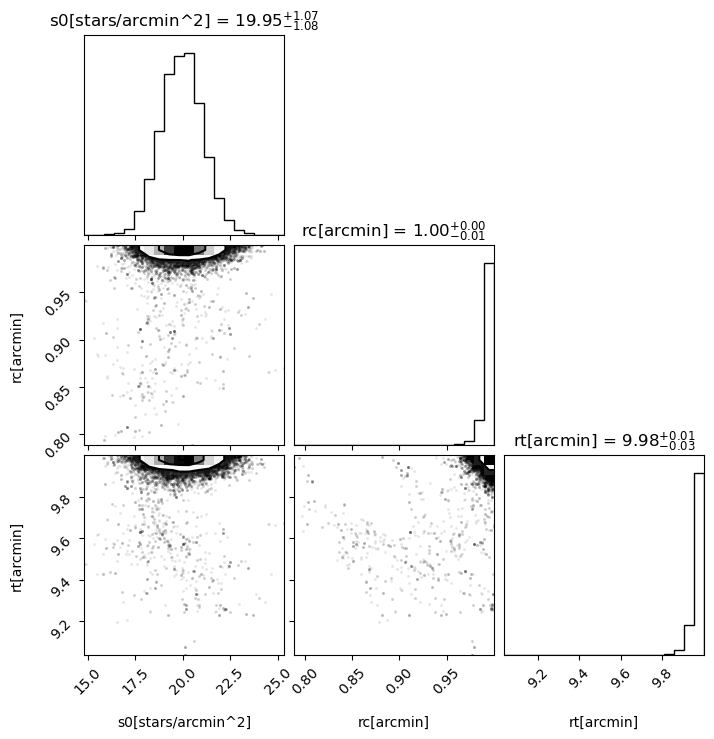

In [18]:
import corner
burn_in = 400
labels = ["s0[stars/arcmin^2]", "rc[arcmin]", "rt[arcmin]"]
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)
print("Sampler Running")
sampler.run_mcmc(pos, nsteps, progress = True)
samples_flat = sampler.get_chain(discard = burn_in, flat = True)

fig = corner.corner(samples_flat, labels = labels, show_titles = True)
plt.show()

We can see that all of the parameter plots (except for the s0 plot) have the general shape of a Gaussian, but are skewed to the extreme permitted values. The final value for the core radius is 1, which coincides with the upper limit we set earlier. The same thing happens with the tidal radius, where the final value is 9.98 (+0.02, -0.03), right at the edge of the bounds. For s0 none of this truncation is happening, and it seems like there is a pretty good non-skewed Gaussian distribution. I suspect this is because the priors we took are not representative of the cluster, and that we need to shift our values to see a better fit. In particular the rc and rt values are much too low. We can compare them to a basic histogram of the radially binned stars, and easily see that the tidal radius (the radius at which the King model becomes 0), is at least 60 in our cluster, and that the core radius should be aorund 20. This does not happen for the central surface density, since we do not set that kind of boundary. 

### d. Posterior predictive check

I am generating the replicated datasets by randomly selecting one sample at a time, generating a King model using the sample, approximating the number of stars per bin, adding poisson noise, and then plotting them. In magenta, I also plot the observed values to check how well the simulated datasets look compared to the data.

Text(0.5, 1.0, 'Posterior Predictive Plot')

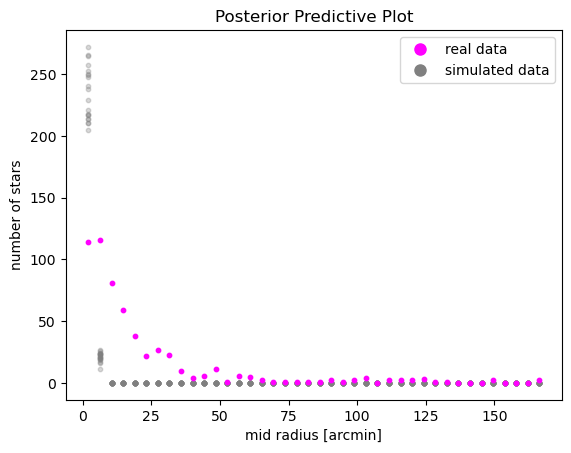

In [19]:
from matplotlib.lines import Line2D
import random

draws = 20
for i in range(draws):
    # Pick random generated sample
    random_sample = samples_flat[random.randint(0, len(samples))]
    # Generate model using this sample
    r = mid_rad_40
    k_sigmas = sigma_king_cluster(r, random_sample[0], random_sample[1], random_sample[2])
    k_sigmas[r>random_sample[2]] = 0
    k_n = np.array(k_sigmas * area_40) #estimated counts per bin
    k_n = k_n + np.random.poisson(k_n)
    plt.scatter(mid_rad_40, k_n, color = "gray", alpha = 0.3, s = 10, label = "a")

legend = [Line2D([0], [0], lw = 0, marker='o', color='magenta', label='real data', markerfacecolor='magenta', markersize=8),
          Line2D([0], [0], lw = 0, marker='o', color='gray', label='simulated data', markerfacecolor='gray', markersize=8)]
plt.scatter(mid_rad_40, hist_40[0], color = "magenta", s = 10, label = "real data")
plt.title("Posterior Predicted check")
plt.legend(handles = legend)
plt.xlabel("mid radius [arcmin]")
plt.ylabel("number of stars")
plt.title("Posterior Predictive Plot")

It looks like my earlier suspicion is correct. As described, the simulated data does not describe the real data that we have because the tidal radius and the core radius are both too small. This can be seen in the way that the values for the number of stars in each bin falls rapidly, converging onto 0 far before the actual data does. At first I thought that this meant that something in my assumptions or priors was wrong, but I believe it is a byproduct of how extended my cluster is. I've cross-checked with my classmates and it seems that for smaller clusters, the set tidal radius limit of 10 allows the King model to speculate on the number of stars per bin for ~5 bins, as opposed to my 2 bins. However, the overall shape looks to be correct, and I believe that with some prior massaging I can find a better fit.  

### e. Computing posterior medians and 68% credible intervals


In [20]:
import arviz as az
# Compute posterior median

s0_mean = np.median(samples[:, :, 0])
rc_mean = np.median(samples[:, :, 1])
rt_mean = np.median(samples[:, :, 2])
means = [s0_mean, rc_mean, rt_mean]
for i in range (0, 3):
    percentiles = np.percentile(samples[:, :, i], [16, 50, 84])
    print(f"The mean of {valnames[i]} is {percentiles[1]}, with 68% credible interval: {percentiles[0]} - {percentiles[2]} [{valdim[i]}]")

The mean of s0 is 19.94973174326185, with 68% credible interval: 18.865988193163744 - 21.015118923719058 [stars/arcmin^2]
The mean of rc is 0.9961288940053562, with 68% credible interval: 0.9898446853677193 - 0.9990685580985467 [arcmin]
The mean of rt is 9.980965424884264, with 68% credible interval: 9.949287327377295 - 9.995436130540927 [arcmin]


Above are shown the mean values for each posterior, along with the 68% credible interval, meaning that the probability that each values falls within that range is 68%. The credible interval being so tight near the upper limits for both rc and rt is another indicator that the priors are not correct.

### f. Interpretation  

Based on the plots and values I have so far computed, I would say that the posteriors I derived cannot be used to draw scientific conclusions about the cluster. This can be seen in the following ways:

1. #### The chain trace plots:
The chain trace plots represent the Markov Chain Monte Carlo Sampling process as described in the lecture. We can clearly see in those plots that for every value there is a number of initial steps during which the value converges on a preferred value. The s0 plot is an example of what this chain should look like. In the rc and rt chains, we can clearly see that while the value does seem to converge, it is squeezed against the artificially set upper limit of 1 and 10 respectively. This is a clue that the priors are not well defined.   

2. #### The corner plot:
The corner plot is another vizualization of the same problem. The diagonals histograms show that the rc and rt values are being cut off by the limit and, as a result, the scatter plots seem to be "off-center". The scatter plots should look more like the scatter plots from last assignment (the parameters are totally different, but I mean they should not have concentrated values around the edges like that)

3. #### The Posterior Predictive plot:  
This plot specifically shows how the faliure in the prior setting fails to reproduce the real data. It shows that the sampled data from the King model converges onto 0 faster than it should, and it gives us a clue as to what the real priors should be.

## 5. Priors Revisited


### a.
_Based on the results from the previous part, discuss whether the initial priors are a reasonable choice, what kind of 
adjustment you might make to improve them, and how you expect that adjustment to affect the diagnostics you 
computed in the previous section._  

As outlined in the previous part, I do not believe the prior ranges are a resonable choice. I do, however, believe that the overall shape of the priors is good. The surface density having a half-gaussian profile makes sense, and the rc and rt values do realistically have to be between 2 values (there is probably a more complicated physical distribution here, but the uniform distribution is a good approximation with our lack of knowledge). This is exactly what was tripping us up in the previous exercise (a uniform distribution by definition has probability 0 outside the range), so we need to be careful with how we pick the new ones. To find the new prior value guesses and their range, we can take a look at the King formula and what the values actually represent. 

*rc* : This is the core radius, where the apparent surface luminosity is dropped by a half. I assume and all stars have the same luminosity, and take this number to be the same as the radius at which the number of stars has dropped by a half. In this cluster's case, a safe guess would be ~20 arcmins. The rc also needs to be larger than 0, like last time, but smaller than 50 arcmins, when we get into the really low values (we can also take the upper limit to be rmax here! it should not really matter).

*rt* : The radius at which the gravitational effects of the galaxy overpower those of the cluster. The King model assumes that the surface density at radii above this value is 0. We can look at the star nr vs radius plot and see that the number of stars come close to 0 at ~70 arcmins. I will keep the restriction that rt needs to be larger than rc since it makes sense with the physical interpretation (if the surface density is 0, the luminosity will have dropped by half way before that radius), but I will up the upper limit to the maximum radius of the cluster.

*s0* : This is the central surface density, or the surface density at radius 0. In the King model, at r=0, this term is scaled by  $1/sqrt(1+(rt/rc)^2)$. For our previous values, this term is 0.07. Now that we know that s0 multiplied by 0.07 equals the surface density of the innermost cluster (~2.1), we can calculate a good s0 estimate to be 28.  

I expect that changing the priors in this way will give us a better corner plot with clear Gaussian distributions, and a much better overlap between the sampled and real data. In addition, I expect that we will see an inverse linear correlation between the core radius and central surface density, since the smaller the core radius is, the more compressed the core, and the more dense its surface.

### b. 
_Rank the three options from most to least appropriate, and justify your rankings in a short paragraph_

Here they are from most to least appropriate: 

𝑟c∼𝑈𝑛𝑖𝑓𝑜𝑟𝑚(0,𝑅max), where 𝑅max is the largest bin size - This in my opinion is the best one yet because it lets the core radius take on all of the physically feasable values, and the margins are not arbitrary, but based on real physical parameters that are also not directly involved in the model, so there is no risk of circualar dependences.

rc∼𝐿𝑜𝑔𝑈𝑛𝑖𝑓𝑜𝑟𝑚(−5,log2𝑟t) - Not bad! This range cuts off some of the very small inner values that we can safely throw out. The log form also balances the values such that larger orders of magnitude are not unfairly weighed. It does however, depend on rt, and rt already depends on rc. Unless we change the prior for rt, this is not a very good option because it leads to some circular dependences. Aditionally, the log(2rt) term means that at the highest possible value, rc would be twice the value of rt, which is not physical, like we established earlier.

𝑟c∼𝑈𝑛𝑖𝑓𝑜𝑟𝑚(0,0.5) - Not a good prior. This one is even more constricting than the last, so it will not allow rc to reach the desired value at all, since the probability is 0 outside the range. Could only work for a very very small cluster, but not at all in our case. The 0.05 value is also much lower than that of the width of a bin, and seemingly arbitrary.

### c. 
_For 𝑟, first check whether your cluster has a Wikipediai page, with a tidal radius and distance given. If so, note the the 
given tidal radius  and its uncertainty_

My cluster does not have a Wikipedia page, and I cannot find appropriate values anywhere else. For a Gaussian distribution, I need values for the mean of the distribution and the standard deviation. A natural choice for the mean is the point at which I see the King model converging onto 0, which is ~70 as discussed before. For the standard deviation, I will choose the width of three bins to connect it to the scale of the cluster. This choice also makes sense with the values we can see in the radial profile, where the number of stars per annulus does seem to go to 0 at 70, but there is some wiggle room around this value, where the tidal radius should be able to move to adjust the shape of the model.

### d. Implement your new priors, re-run your MCMC chain and compute the same diagnostics as before.

Sigma 0, Core Radius, Tidal radius:
[[  4.99998058   9.99999583 159.9999227 ]
 [  5.00000475  10.00000211 160.00003902]
 [  5.00001255   9.99992415 160.00000945]
 [  4.99995538   9.99992763 160.00004383]
 [  5.00001604  10.00006263 160.00002597]
 [  4.99992061   9.99996652 160.00001523]
 [  4.99997197  10.00010392 159.99996841]
 [  5.00007927  10.00003736 159.99995647]
 [  5.00005827  10.00000084 160.0000739 ]
 [  4.9999668    9.99997284 160.00001971]]
Sampler Running


100%|██████████████████████████████████████████████████████████████████████████████████████████| 7000/7000 [00:35<00:00, 197.81it/s]


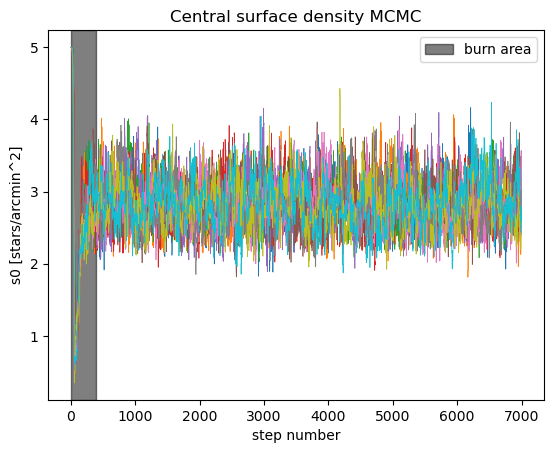

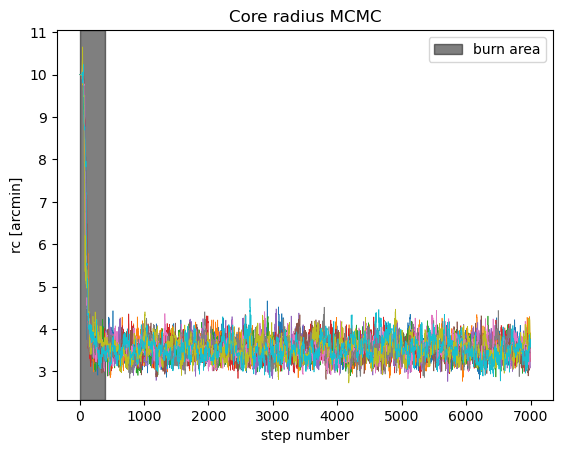

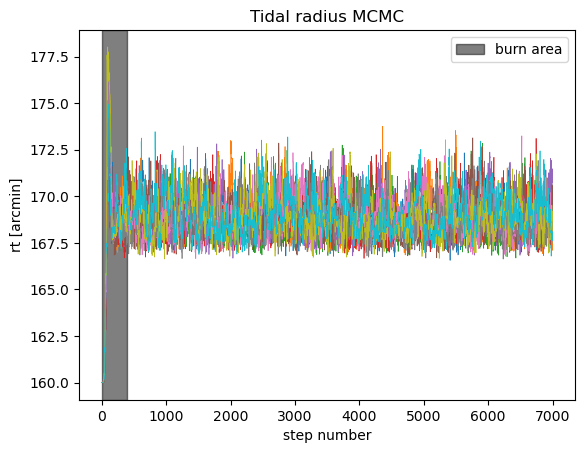

In [21]:
# Implementing new prior and defining new log-posterior function

def log_gaussian(x, mu, sigma):
    """
    Log-pdf of a Normal (Gaussian) distribution.

    Parameters
    ----------
    x : float or np.ndarray
        Point(s) at which to evaluate the log-density.
    mu : float
        Mean of the Normal distribution.
    sigma : float
        Standard deviation of the Normal distribution. Must be > 0.

    Returns
    -------
    logp : float or np.ndarray
        Log-density evaluated at `x`. Returns `-np.inf` where parameters
        are invalid (e.g., sigma <= 0) or where evaluation is undefined.
    """
    x = np.asarray(x)
    if not np.isfinite(mu) or not np.isfinite(sigma) or sigma <= 0:
        return np.full_like(x, -np.inf, dtype=float) if x.ndim else -np.inf

    z = (x - mu) / sigma
    logp = -0.5 * (np.log(2.0 * np.pi) + 2.0 * np.log(sigma) + z**2)
    return logp

# First the log-prior function
bin_width = bins_40[1]
def total_log_prior_new(values):
    """
    Total log pdf for a Half-Normal, Uniform, and Gaussian profile

    values : iterable
        Values used in the Kingmodel, arranged in the order: Central surface density, core radius, tidal radius

    Returns
    -------
    posterior : the total log-prior
    """
    return(log_halfnormal(values[0], 1) + log_uniform(values[1], 0, rmax) + log_gaussian(values[2], 160, 0.5*bin_width))

# Then the log posterior
def log_posterior_new(k):
    """
    Computes the log-posterior given the initial parameters using the King Poisson likelihood and the total log prior

    Parameters
    ----------
    k : iterable
        Values used in the Kingmodel, arranged in the order: Central surface density, core radius, tidal radius

    star_nr, bins : iterable, iterable
        Number of stars and bin edges (per individual bin)

    Returns
    -------
    posterior : the log-posterior    
    """
    a=total_log_prior_new(k)
    if not np.isfinite(a):
        return -np.inf
    posterior = like(k, hist_40[0], bins_40, area_40) + total_log_prior_new(k)
    return (posterior)

# Running MCMC again, with same diagnostics

# Initializing variables
nsteps = 7000
initial = np.array([5, 10, 160]) # Initializing value guesses
pos = initial + (np.exp(-10)*np.random.randn(nwalkers, ndim))
print("Sigma 0, Core Radius, Tidal radius:")
print(pos)

# Run MCMC
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior_new) # Using same variables
print("Sampler Running")
sampler.run_mcmc(pos, nsteps, progress = True)
samples = sampler.get_chain(discard = 0, flat = False)

# Diagnostics - trace plots
valtext = ["Central surface density", "Core radius", "Tidal radius"]
valnames = ["s0", "rc", "rt"]
valdim = ["stars/arcmin^2", "arcmin", "arcmin"]
for i in range(0, 3):
    plt.plot(samples[:, :, i], alpha = 1, linewidth = 0.5)
    plt.title(f"{valtext[i]} MCMC")
    plt.xlabel("step number")
    plt.ylabel(f"{valnames[i]} [{valdim[i]}]")
    plt.axvspan(0, 400, alpha=0.5, color='black', label = "burn area")
    plt.legend()
    plt.show()


Sampler Running


100%|██████████████████████████████████████████████████████████████████████████████████████████| 7000/7000 [00:36<00:00, 192.31it/s]


7000
Integrated autocorrelation times:
 Central surface density: [49.13761772]
 Core radius: [48.08414742]
 Tidal radius: [43.19558835]
Effective sample sizes:
 Central surface density: [134.3166459]
 Core radius: [137.25937455]
 Tidal radius: [152.79338127]
New step count:
 Central surface density: [324308.27697238]
 Core radius: [317355.37294036]
 Tidal radius: [285090.8831142]
Sampler Running


100%|██████████████████████████████████████████████████████████████████████████████████████████| 7000/7000 [00:46<00:00, 150.48it/s]


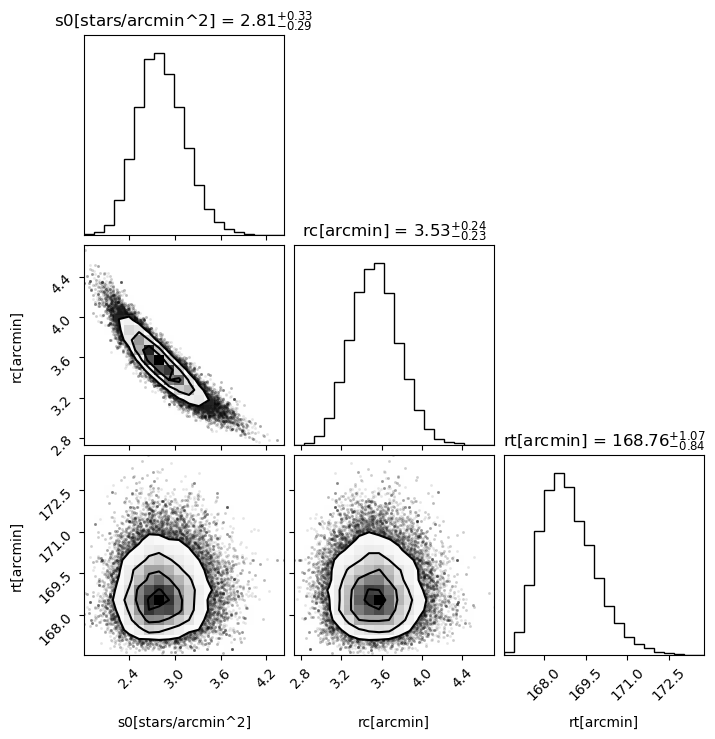

In [22]:
burn_in = 400
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior_new)
print("Sampler Running")
sampler.run_mcmc(pos, nsteps, progress = True)
samples = sampler.get_chain(discard = burn_in, flat = False) 


# Computing integrated autocorrelation time for each parameter

nsteps_new = nsteps - burn_in
ts0 = emcee.autocorr.integrated_time(samples[:,:,0], c=5, tol=50, quiet=False)
trc = emcee.autocorr.integrated_time(samples[:,:,1], c=5, tol=50, quiet=False)
trt = emcee.autocorr.integrated_time(samples[:,:,2], c=5, tol=50, quiet=False)

print(nsteps)
print(f"Integrated autocorrelation times:\n Central surface density: {ts0}\n Core radius: {trc}\n Tidal radius: {trt}")
print(f"Effective sample sizes:\n Central surface density: {nsteps_new/ts0}\n Core radius: {nsteps_new/trc}\n Tidal radius: {nsteps_new/trt}")
print(f"New step count:\n Central surface density: {nsteps_new*ts0}\n Core radius: {nsteps_new*trc}\n Tidal radius: {nsteps_new*trt}")

import corner
burn_in = 400
labels = ["s0[stars/arcmin^2]", "rc[arcmin]", "rt[arcmin]"]
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior_new)
print("Sampler Running")
sampler.run_mcmc(pos, nsteps, progress = True)
samples_flat = sampler.get_chain(discard = burn_in, flat = True)

fig = corner.corner(samples_flat, labels = labels, show_titles = True)
plt.show()

Text(0.5, 1.0, 'Posterior Predictive Plot')

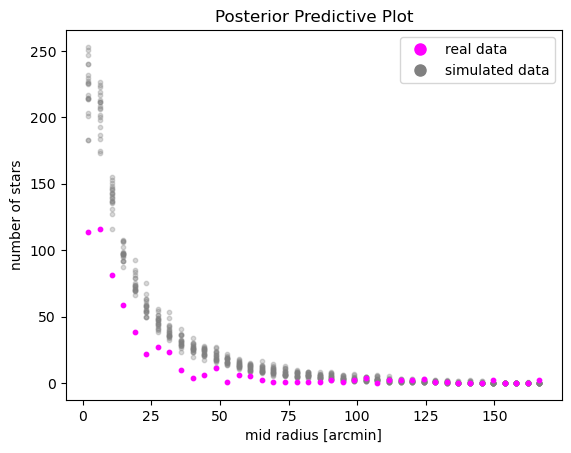

In [23]:
from matplotlib.lines import Line2D
import random

draws = 20
for i in range(draws):
    # Pick random generated sample
    random_sample = samples_flat[random.randint(0, len(samples))]
    # Generate model using this sample
    r = mid_rad_40
    k_sigmas = sigma_king_cluster(r, random_sample[0], random_sample[1], random_sample[2])
    k_n = np.array(k_sigmas * area_40) #estimated counts per bin
    k_n = k_n + np.random.poisson(k_n)
    plt.scatter(mid_rad_40, k_n, color = "gray", alpha = 0.3, s = 10, label = "a")

legend = [Line2D([0], [0], lw = 0, marker='o', color='magenta', label='real data', markerfacecolor='magenta', markersize=8),
          Line2D([0], [0], lw = 0, marker='o', color='gray', label='simulated data', markerfacecolor='gray', markersize=8)]
plt.scatter(mid_rad_40, hist_40[0], color = "magenta", s = 10, label = "real data")
plt.title("Posterior Predicted check")
plt.legend(handles = legend)
plt.xlabel("mid radius [arcmin]")
plt.ylabel("number of stars")
plt.title("Posterior Predictive Plot")

i. Is the MCMC sampler converged?  

Yes, we can see that the MCMC sampler has converged from the Trace plot diagnostic. All values are within a specific range, and there does not seem to be any obvious trend in the behaviours of the chains after the initial burn-in beriod. We can also look at the integrated auto-correlation times and see that they hover around 60, which is an acceptable value.

ii. Comment on any surprising features in the corner plot that you’ve made, and name one reason per feature you identify that could explain them.   

As you can see in the code, I had to adjust the parameters for the likelihoods quite a lot. In particular, when running the MCMC with a tidal radius mean of 70 as initially discussed, the chain would often converge onto 2 or more different values (~110, 140, etc.). I suspect this is because of a feature of the King model, which assumes that at any radius over the tidal radius, the surface density (and therefore star count) drops to 0. However, we took the bins in such a way that the number of stars does not conclusively drop to 0 until the very outer radius. This means that the tidal radius corresponds to the outer radius for our cluster. In other words, the King model assumption that the tidal radius coincides with the radius at which we have no stars fails, because of the stolen cluster of stars we can see in the star map. This splitting of the Markof chains resulted in there being 2 gaussian peaks for the rt variable, which has been fixed with the new initial value. Predictably, since the MCMC sampling does not deal well with the double peaks, this was reflected in the other areas of the corner plot.  

We can also see, as predicted, an inverse linear relationship between the rc and s0. As argued before, this makes sense because the more dense the core of the cluster is, the smaller its radius is going to be.  

Another feature is the rt drifting into values over the maximum radius. This makes sense because only over the maximum radius of the cluster do we have a 0 density of stars.  

iii. Is the posterior predictive distribution a better approximation to the real data than for the previous prior? What has changed? Are there features in the data that are still not well-explained by the model? 

The posterior predictive plot shows that the model does not do a good job of fitting the innermost bins. I believe this might occur due to the issues with the tidal radius forcing the inner density up so that the model can fit most of the middle - outer bins better. I have attemped to fix this issue by setting the tidal radius over the max radius, at ~200, but it shows no improvement on the fit of the inner bins. For the mid to outer bins, however, the model fit has improved! In the previous PPS plot we can see the simulated data converges onto 0 much sooner than necessary, such that the mid to outer bins are all assumed to have 0 stars, which is not true. This rt=168 does, however, have an issue. It is often leading to the overestimation of stars in a bin. The model also fails to fit the particular inner structures of the cluster.

iv. Compute posterior medians and credible intervals for all parameters, and compare these to the posterior medians 
and credible intervals computed on the MCMC chains using the previous priors

In [24]:
s0_mean = np.median(samples[:, :, 0])
rc_mean = np.median(samples[:, :, 1])
rt_mean = np.median(samples[:, :, 2])
means = [s0_mean, rc_mean, rt_mean]
for i in range (0, 3):
    percentiles = np.percentile(samples[:, :, i], [16, 50, 84])
    print(f"The median of {valnames[i]} is {percentiles[1]}, with 68% credible interval: {percentiles[0]} - {percentiles[2]} [{valdim[i]}]")

The median of s0 is 2.8112049072902927, with 68% credible interval: 2.5249575931796473 - 3.1380245660312154 [stars/arcmin^2]
The median of rc is 3.531507634403062, with 68% credible interval: 3.299817158239723 - 3.7700252213633827 [arcmin]
The median of rt is 168.76410391837635, with 68% credible interval: 167.92152214147313 - 169.83551645812372 [arcmin]


Comparing these to the posterior medians to the previous:  

The median of s0 is 20.027882524619773, with 68% credible interval: 18.903279448483467 - 21.128939274842484 [stars/arcmin^2]  
The median of rc is 0.9963519585150946, with 68% credible interval: 0.9905120545195589 - 0.99913875115846 [arcmin]  
The median of rt is 9.980355171748354, with 68% credible interval: 9.948710150394891 - 9.995201495278607 [arcmin]  

We can see that the values have changed greately, but the interval dimensions have remained similar in size. This might mean that the model just naturally fits the values in a tight interval.